In [2]:
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
vect = CountVectorizer(ngram_range=(1, 1))
vect.fit_transform(['nothing is impossible', 'everything is possible']).toarray()

array([[0, 1, 1, 1, 0],
       [1, 0, 1, 0, 1]])

In [4]:
vect.vocabulary_

{'nothing': 3, 'is': 2, 'impossible': 1, 'everything': 0, 'possible': 4}

In [5]:
vect = CountVectorizer(ngram_range=(1, 2))
vect.fit_transform(['nothing is impossible', 'everything is possible']).toarray()

array([[0, 0, 1, 1, 1, 0, 1, 1, 0],
       [1, 1, 0, 1, 0, 1, 0, 0, 1]])

In [6]:
vect.vocabulary_

{'nothing': 6,
 'is': 3,
 'impossible': 2,
 'nothing is': 7,
 'is impossible': 4,
 'everything': 0,
 'possible': 8,
 'everything is': 1,
 'is possible': 5}

# N-граммы из букв

In [7]:
from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
vect = CountVectorizer(ngram_range=(3, 3), analyzer='char_wb')
n1, n2, n3, n4 = vect.fit_transform(['иванов', 'петров', 'петренко', 'смит']).toarray()
euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)

(np.float64(3.1622776601683795),
 np.float64(2.8284271247461903),
 np.float64(3.4641016151377544))

# Изображения

In [9]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
import numpy as np

I0000 00:00:1781099213.873295   31700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781099214.006492   31700 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/hei3enberg/miniconda3/envs/DataScienceStudy/lib/python3.13/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [10]:
resnet_settings = {'include_top': True, 'weights': 'imagenet'}
resnet = ResNet50(**resnet_settings)

img = image.load_img('images.jpeg')
img_array = image.img_to_array(img)

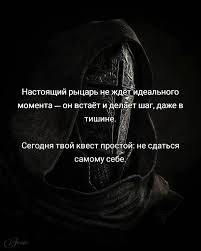

In [11]:
img

In [12]:
img = img.resize((224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

features = resnet.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [13]:
features

array([[4.18141535e-05, 5.08754674e-05, 6.74047697e-05, 1.05360436e-04,
        8.92368698e-05, 1.60051291e-04, 3.81017981e-06, 3.25302535e-05,
        6.92107915e-06, 2.33720348e-05, 3.11278404e-06, 1.07795017e-06,
        2.00440104e-06, 1.01996284e-06, 6.65855259e-06, 2.12373448e-06,
        1.89359605e-06, 1.69372515e-06, 4.80460494e-06, 2.51131723e-06,
        9.10085055e-06, 2.64159189e-06, 1.42981344e-05, 5.46549290e-06,
        1.04409355e-05, 2.97754941e-05, 9.49541063e-05, 3.21372245e-05,
        9.52559276e-06, 2.08999518e-05, 6.26646306e-06, 2.42935812e-06,
        2.34442068e-05, 3.60634876e-05, 2.89436866e-05, 7.94311927e-06,
        1.46028760e-05, 1.09383063e-06, 3.56248129e-05, 1.41764838e-06,
        3.65659025e-06, 1.87549558e-05, 5.66129938e-06, 3.29589093e-05,
        1.74280558e-05, 2.76438204e-05, 1.68449492e-06, 5.36439620e-05,
        1.66760383e-05, 3.53079372e-06, 1.29255364e-04, 3.17776576e-05,
        1.05249368e-04, 5.96033460e-05, 7.82981151e-05, 1.292972

# Чтение текста с картинки

In [14]:
import pytesseract
from PIL import Image
import requests
from io import BytesIO

In [16]:
img = 'http://ohscurrent.org/wp-content/uploads/2015/09/domus-01-google.jpg'
img = requests.get(img)
img = Image.open(BytesIO(img.content))
text = pytesseract.image_to_string(img)
print(text)

KeyboardInterrupt: 

In [ ]:
img = "https://habrastorage.org/webt/mj/uv/6o/mjuv6olsh1x9xxe1a6zjy79u1w8.jpeg"
img = requests.get(img)
img = Image.open(BytesIO(img.content))
text = pytesseract.image_to_string(img)
print(text)

# Временные ряды, веб и прочее

In [17]:
import user_agents

ua = "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Ubuntu 16.04 Chromium/56.0.2924.76 Chrome/56.0.2924.76 Safari/537.36"
ua = user_agents.parse(ua)

print("Is a bot? ", ua.is_bot)
print("Is mobile? ", ua.is_mobile)
print("Is PC? ", ua.is_pc)
print("OS Family: ", ua.os.family)
print("OS Version: ", ua.os.version)
print("Browser Family: ", ua.browser.family)
print("Browser Version: ", ua.browser.version)

Is a bot?  False
Is mobile?  False
Is PC?  True
OS Family:  Ubuntu
OS Version:  (16, 4)
Browser Family:  Chromium
Browser Version:  (56, 0, 2924)


# Нормализация данных

In [19]:
import numpy as np
from scipy.stats import beta, shapiro
from sklearn.preprocessing import StandardScaler

# Z-score normalization
data = beta(1, 10).rvs(1000).reshape(-1, 1)
shapiro(data)

ShapiroResult(statistic=np.float64(0.8782112037115647), pvalue=np.float64(2.931428078901914e-27))

In [20]:
data = np.array([1, 1, 0, -1, 2, 1, 2, 3, -2, 4, 100]).reshape(-1, 1).astype(np.float64)
StandardScaler().fit_transform(data)

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [ ]:
# Z-score normalization формула
(data - data.mean()) / data.std()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
MinMaxScaler().fit_transform(data)

In [ ]:
# MinMax Scaling формула
(data - data.min()) / (data.max() - data.min())

In [ ]:
from scipy.stats import lognorm

In [ ]:
# Логнормальное распределение
data = lognorm(s=1).rvs(1000)
shapiro(data)

In [ ]:
shapiro(np.log(data))

# Feature selection

In [ ]:
# Статистические подходы

from sklearn.datasets import make_classification
from sklearn.feature_selection import VarianceThreshold

x_data_generated, y_data_generated = make_classification()
x_data_generated.shape

In [ ]:
VarianceThreshold(0.7).fit_transform(x_data_generated).shape

In [ ]:
VarianceThreshold(0.8).fit_transform(x_data_generated).shape

In [ ]:
VarianceThreshold(0.9).fit_transform(x_data_generated).shape

In [ ]:
# Отбор с использованием моделей

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [ ]:
x_data_generated, y_data_generated = make_classification()

pipe =  make_pipeline(SelectFromModel(estimator=RandomForestClassifier()), LogisticRegression())
lr = LogisticRegression()
rf = RandomForestClassifier()

print(cross_val_score(lr, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())
print(cross_val_score(rf, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())
print(cross_val_score(pipe, x_data_generated, y_data_generated, scoring='neg_log_loss').mean())

In [ ]:
x_data = x_data_generated
y_data = y_data_generated

pipe1 = make_pipeline(StandardScaler(), SelectFromModel(estimator=RandomForestClassifier()), LogisticRegression())
pipe2 = make_pipeline(StandardScaler(), LogisticRegression())

rf = RandomForestClassifier()

print("LR + selection: ", cross_val_score(pipe1, x_data, y_data, scoring='neg_log_loss').mean())
print("LR: ", cross_val_score(pipe2, x_data, y_data, scoring='neg_log_loss').mean())
print("RF: ", cross_val_score(rf, x_data, y_data, scoring='neg_log_loss').mean())

In [ ]:
# перебор
# самый надежный, но и вычислительно затратный метод
from mlxtend.feature_selection import SequentialFeatureSelector

In [ ]:
selector =  SequentialFeatureSelector(LogisticRegression(),
                                      scoring='neg_log_loss',
                                      verbose=2,
                                      k_features=3,
                                      forward=False,
                                      n_jobs=-1)

selector.fit(x_data, y_data)